# **_Sample Modeling_** (for Reinforcement Learning with LSTM)

* 이 페이지는 "Drying Oven"의 가상 센서 데이터를 이용하여 PPO 모델을 교육하고 예측하는 예제를 구현합니다. 
* 이 페이지에서는 Liear 대신에 LSTM을 이용하도록 변경합니다.

In [2]:
# ----------------------------------------------------
# Global 변수 선언
# ----------------------------------------------------

csv_file_name = "drying_oven_sensor_v4.csv"
model_path_name = "./recurrent_ppo_dryer_control.pth"
conf_num_samples = 80000

In [7]:
# ----------------------------------------------------
# Common Import
# ----------------------------------------------------
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from stable_baselines3.common.callbacks import BaseCallback
import time
from datetime import datetime
import gymnasium as gym
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import CheckpointCallback
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor

### Step 1 가상 센서 데이터 생성

**시나리오**

* 데이터 생성 시나리오
  - 센서 데이터(내부 온도, 습도, 무게, 외부 온도, 팬의 rpm, 압력)와 사용자 조치 데이터(팬의 rpm 절을 위한 행동 데이터, 업/다운)
  - 내부 온도의 목표 온도는 80도 입니다.
  - 초기 가열은 10% 정도이며, 중간에 1차례의 급격한 온도 하강과 1차례의 온도 상승이 있습니다.
  - 사용자 조치 데이터는 센서 데이터를 기반으로 내부 온도가 목표 온도를 유지하도록 하기 위한 조치의 데이터입니다.

* 건조기의 가상 데이터를 생성했습니다. 이 데이터는 목표 온도인 80도를 유지하기 위해 사용자가 팬의 RPM을 조절하는 시나리오를 담고 있습니다.

* 데이터 생성 로직 및 조건 반영
  * 목표 온도: 80도를 기준으로 설정되었습니다.
  * 초기 가열 (0~10%): 25도에서 시작하여 10번째 샘플까지 점진적으로 상승합니다.
  * 급격한 변화:
    * 하강 (40~44 지점): 문 열림 등의 상황을 가정하여 약 25도 급락하며, 사용자는 열 보존을 위해 팬 RPM을 낮춥니다 (DOWN).
    * 상승 (70~74 지점): 히터 과부하 등을 가정하여 약 15도 급등하며, 사용자는 열 배출을 위해 팬 RPM을 높입니다 (UP).
  * 사용자 조치 데이터:
    * inner_temp < 78: 팬 RPM을 낮추는 조치 (DOWN)
    * inner_temp > 82: 팬 RPM을 높이는 조치 (UP)
    * 78 <= inner_temp <= 82: 현재 상태 유지 (KEEP)
  * 기타 센서: 습도는 시간이 지남에 따라 감소(80% → 15%)하고, 무게는 수분 증발로 인해 미세하게 줄어듭니다.

In [22]:
import pandas as pd
import numpy as np

# 1. 설정값 초기화
num_samples = conf_num_samples
target_temp = 80
initial_temp = 25

# 시간축 (초 단위 가정)
time = np.arange(num_samples)

# 2. 내부 온도(inner_temp) 생성 로직
inner_temp = np.full(num_samples, target_temp, dtype=float)

# 초기 가열 구간 (0~10%)
heating_end = int(num_samples * 0.1)
inner_temp[:heating_end] = np.linspace(initial_temp, target_temp, heating_end)

# 급격한 온도 하강 시나리오 (40% 지점, 예: 문 열림)
drop_start = int(num_samples * 0.4)
drop_duration = 100 # 변화 지속 시간
inner_temp[drop_start:drop_start+drop_duration] -= np.linspace(0, 30, drop_duration)
# 복구 구간
inner_temp[drop_start+drop_duration:drop_start+drop_duration*2] = np.linspace(inner_temp[drop_start+drop_duration-1],
                                                                              target_temp,
                                                                              drop_duration)

# 급격한 온도 상승 시나리오 (50,60,70,80% 지점, 예: 히터 과열)
spike_env = [(0.5,100), (0.6,2000), (0.7,300), (0.8,100)]
for i in range(len(spike_env)):
    ratio, duration = spike_env[i]
    spike_start = int(num_samples * ratio)
    inner_temp[spike_start:spike_start+duration] += np.linspace(0, 80, duration)
    # 복구 구간
    inner_temp[spike_start+duration:spike_start+duration*2] = np.linspace(inner_temp[spike_start+duration-1],
                                                                          target_temp,
                                                                          duration)

# 미세 노이즈 추가 (실제 데이터 느낌 부여)
inner_temp += np.random.normal(0, 0.4, num_samples)

# 3. 기타 센서 데이터 생성
humidity = np.linspace(80, 15, num_samples) + np.random.normal(0, 1, num_samples) # 습도 점진적 감소
weight = np.linspace(5.0, 4.2, num_samples) + np.random.normal(0, 0.01, num_samples) # 무게 감소
outer_temp = np.random.normal(22, 1, num_samples) # 외부 온도 (평균 22도)
pressure = np.random.normal(1013, 2, num_samples) # 대기압

# 4. 사용자 조치 및 팬 RPM 결정 (Down:0, Keep: 1, Up:2)
def determine_action(temp):
    if temp < 78: return "0"   # 온도가 낮으면 팬 속도 감소(열 보존)
    elif temp > 82: return "2" # 온도가 높으면 팬 속도 증가(열 배출)
    else: return "1"           # 적정 온도 유지

actions = [determine_action(t) for t in inner_temp]

# Action에 따른 팬 RPM 수치 할당
fan_rpm = []
for action in actions:
    if action == "0": fan_rpm.append(1200 + np.random.randint(-50, 50))
    elif action == "2": fan_rpm.append(1800 + np.random.randint(-50, 50))
    else: fan_rpm.append(1500 + np.random.randint(-30, 30))

# 5. 데이터프레임 생성 및 확인
df = pd.DataFrame({
    'timestamp': time,
    'inner_temp': np.round(inner_temp, 2),
    'humidity': np.round(humidity, 2),
    'weight': np.round(weight, 3),
    'outer_temp': np.round(outer_temp, 2),
    'pressure': np.round(pressure, 2),
    'fan_rpm': fan_rpm,
    'user_action': actions
})

# 결과 출력 (상위 10개 및 하강 구간 확인)
print("--- 초기 가열 구간 데이터 ---")
print(df.head(10))
print(f"\n--- 온도 하강 발생 구간 데이터 ({drop_start}번 인덱스 부근) ---")
print(df.iloc[drop_start:drop_start+drop_duration])
for i in range(len(spike_env)):
    ratio, duration = spike_env[i]
    spike_start = int(num_samples * ratio)
    print(f"\n--- 온도 상승 발생 구간 데이터 ({spike_start}번 인덱스 부근) ---")
    print(df.iloc[spike_start:spike_start+duration])
# CSV 파일로 저장
df.to_csv(csv_file_name, index=False)

--- 초기 가열 구간 데이터 ---
   timestamp  inner_temp  humidity  weight  outer_temp  pressure  fan_rpm  \
0          0       25.05     80.76   4.996       21.49   1012.08     1202   
1          1       25.04     79.40   5.015       22.14   1012.20     1242   
2          2       25.19     81.16   5.015       22.35   1016.36     1214   
3          3       24.71     79.23   5.006       23.76   1013.33     1180   
4          4       25.49     80.80   5.015       21.94   1014.83     1177   
5          5       25.29     81.38   4.997       20.80   1011.45     1241   
6          6       24.55     79.84   4.996       21.98   1015.00     1212   
7          7       25.79     80.59   5.002       22.53   1015.23     1150   
8          8       25.61     80.79   4.986       22.92   1017.60     1240   
9          9       25.53     80.70   4.993       20.06   1013.53     1164   

  user_action  
0           0  
1           0  
2           0  
3           0  
4           0  
5           0  
6           0  
7  

### Step 2 Env 생성

##### 2.1 보상 함수 (풍압 중심 제어)

**_주요 구성 요소 설명_**

* Observation Space: 이전 가상 데이터의 모든 컬럼을 포함합니다. RecurrentPPO는 내부적으로 이 데이터의 변화 추이를 학습합니다.
* 물리 시뮬레이션: step 함수 내에서 RPM 수치에 따라 온도가 변하도록 설계했습니다. 특히 요청하신 40% 지점 하강, 70% 지점 상승 시나리오를 강제로 발생시켜 모델이 이를 극복하도록 유도합니다.
* Reward Function: 단순히 80도에 가깝게 유지하는 것뿐만 아니라, 범위를 벗어날 경우 패널티를 주어 모델이 "사용자 조치(UP/DOWN)"를 적극적으로 학습하게 합니다.
* RecurrentPPO 활용 팁: Stable-Baselines3-Contrib 라이브러리의 RecurrentPPO를 사용하신다면, policy="MlpLstmPolicy"를 설정하여 이 환경을 바로 학습시킬 수 있습니다.

**_학습 포인트 (Tips for Success)_**

- LSTM 상태 관리: model.predict를 할 때 state와 episode_start 인자를 넘겨주는 것이 핵심입니다. 이를 통해 모델이 이전 시점의 온도 변화(급격한 하강/상승)를 기억하고 대응하게 됩니다.
- 보상(Reward) 튜닝: 만약 모델이 온도를 잘 못 맞춘다면, DryerEnv의 reward = -temp_diff 부분을 reward = -(temp_diff**2) 처럼 제곱으로 바꾸어 오차에 더 민감하게 만들 수 있습니다.
- 데이터 정규화: 실제 환경에서는 온도(25~100)와 무게(4~5)의 수치 범위가 매우 다릅니다. 학습 효율을 높이려면 Stable-Baselines3의 VecNormalize 래퍼를 사용하여 관측치를 0~1 사이로 정규화하는 것을 추천합니다.

In [23]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class DryerEnv(gym.Env):
    """
    RecurrentPPO 학습을 위한 건조기 온도 제어 환경
    목표: 팬 RPM을 조절하여 내부 온도를 80도로 유지하기
    """
    init_sim_data = [{
            "inner_temp": 79.5,  # 실측 온도
            "error_temp": -0.5,  # 실측 온도 - 목표 온도
            "humidity": 45.2,    # 실측 습도
            "weight": 4.65,      # 실측 무게
            "outer_temp": 22.1,
            "pressure": 1012.8,
            "fan_rpm": 1550.0,
        },
        {
            "inner_temp": 25,  # 실측 온도
            "error_temp": 55,  # 실측 온도 - 목표 온도
            "humidity": 80,    # 실측 습도
            "weight": 5.0,      # 실측 무게
            "outer_temp": 22.0,
            "pressure": 1013.0,
            "fan_rpm": 1500.0
        }
    ]

    TARGET_TEMP = 80
    FAN_RPM_STEP = 50
    FAN_RPM_BASE = 1500
    FAN_RPM_LOW  = 0
    FAN_RPM_HIGH = 3000
    TIMESTAMP_MAX = float(pandas.Timestamp.max.timestamp())

    def __init__(self, target_temp=80.0, max_steps=10000, simul_data_gen=True, is_simulatation=True, debug=False):
        super(DryerEnv, self).__init__()

        # 1. Action Space: [0: DOWN, 1: KEEP, 2: UP]
        self.action_space = spaces.Discrete(3)

        # 2. Observation Space: [내부온도, 습도, 무게, 외부온도, 압력, 현재RPM]
        # RecurrentPPO는 이 벡터의 시퀀스를 입력으로 받음
        self.observation_space = spaces.Box(
            low=np.array([0, 0, -10, 0, 0, 0, 900, DryerEnv.FAN_RPM_LOW, target_temp]), 
            high=np.array([DryerEnv.TIMESTAMP_MAX, 150, 90, 100, 10, 50, 1100, DryerEnv.FAN_RPM_HIGH, target_temp]),
            dtype=np.float64
        )
        self.is_simulation = is_simulatation

        self.target_temp = target_temp
        self.max_steps = max_steps
        self.state = np.array([])
        self.terminated = False
        self._debug = debug
        self.current_step = 0
        self.reset(simul_data_gen=simul_data_gen)

    @staticmethod
    def _get_fan_rpm_by_action(fan_rpm, action, debug=False):
        # 2. 액션에 따른 팬 RPM 변화 (사용자의 조치 반영)
        # print("#0 =", action, fan_rpm)
        if action == 0:   # DOWN: RPM 감소 -> 열 배출 감소 -> Heat-gain 증가
            fan_rpm -= DryerEnv.FAN_RPM_STEP
        elif action == 2: # UP: RPM 증가 -> 열 배출 증가 -> Heat-gain 감소
            fan_rpm += DryerEnv.FAN_RPM_STEP
        # print("#1 =", action, fan_rpm)
        # action 1 (KEEP)은 유지
        fan_rpm = np.clip(fan_rpm, DryerEnv.FAN_RPM_LOW, DryerEnv.FAN_RPM_HIGH)
        # print("#2 =", action, fan_rpm)

        return fan_rpm

    @staticmethod
    def _get_temp_change_by_rpm(inner_temp, outer_temp, humidity, fan_rpm, debug=False):
        # 열 평형 방정식 (핵심 로직)
        # 히터는 일정한 열을 공급 (Heater Input)
        heater_input = 10.0 
        # [핵심] 팬 RPM에 비례하는 냉각 계수 (Cooling Coefficient)
        # RPM이 커질수록 cooling_factor가 커져서 빼지는 값이 커짐
        cooling_factor = (fan_rpm / DryerEnv.FAN_RPM_BASE) if fan_rpm > DryerEnv.FAN_RPM_LOW else 0 # 기준 RPM 1500일 때 1.0
        # 외부 온도와의 차이에 의한 열 손실 (Heat Loss)
        # 팬이 빠를수록(cooling_factor ↑), 내부가 더울수록(temp diff ↑) 손실이 커짐
        if debug:
            print(f'DryerEnv._get_temp_change_by_action.heat_diff={type(heat_diff)}, {heat_diff}')
        heat_loss = cooling_factor * (inner_temp - outer_temp) * 0.1
        if debug:
            print(f'DryerEnv._get_temp_change_by_action.heat_loss={type(heat_loss)}, {heat_loss}')
        # 3. 최종 온도 변화
        # 공급(Heater)보다 손실(Loss)이 크면 온도는 떨어짐 (UP 액션 시 발생)
        # 공급(Heater)보다 손실(Loss)이 작으면 온도는 올라감 (DOWN 액션 시 발생)
        temp_change = heater_input - heat_loss
        if debug:
            print(f'DryerEnv._get_temp_change_by_action.temp_change={type(temp_change)}, {temp_change}')
        # 4. 결과 검증 (인지 확인)
        # - UP(2) 클릭 -> RPM 상승 -> cooling_factor 상승 -> heat_loss 상승 -> temp_change 감소 -> 온도 하락
        # - DOWN(0) 클릭 -> RPM 하락 -> cooling_factor 하락 -> heat_loss 하락 -> temp_change 증가 -> 온도 상승
        return temp_change
    
    @classmethod
    def _get_float_from_npfloat(cls, item):
        import numpy
        if isinstance(item, (np.float32, np.float64, numpy.float32, numpy.float64)):
            return item.item()
        return item

    @staticmethod
    def _generate_simul_data(state, user_action, target_temp, terminated=False, debug=False):
        _, inner_temp, error_temp, humidity, weight, outer_temp, pressure, fan_rpm, target_temp = state
        # get new fan_rpm by action
        fan_rpm = DryerEnv._get_fan_rpm_by_action(fan_rpm=fan_rpm, action=user_action)
        # 습도 및 무게 자연 감소
        humidity = max(15.0, humidity - 0.01)
        weight = max(4.2, weight - 0.0001)

        humidity = DryerEnv._get_float_from_npfloat(humidity)
        weight = DryerEnv._get_float_from_npfloat(weight)
        pressure = DryerEnv._get_float_from_npfloat(pressure)

        # if debug:
        #     print(f'DryerEnv._generate_simul_data.inner_temp={inner_temp}')
        #     print(f'DryerEnv._generate_simul_data.outer_temp={outer_temp}')            
        #     print(f'DryerEnv._generate_simul_data.fan_rpm={fan_rpm}')
        #     print(f'DryerEnv._generate_simul_data.humidity={humidity}')
        #     print(f'DryerEnv._generate_simul_data.weight={weight}')

        temp_change = DryerEnv._get_temp_change_by_rpm(inner_temp=inner_temp,
                                                       outer_temp=outer_temp,
                                                       humidity=humidity,
                                                       fan_rpm=fan_rpm,
                                                       debug=debug)
        if debug:
            print(f'DryerEnv._generate_simul_data.heat_change={temp_change}')
        
        inner_temp = inner_temp + temp_change
        # if debug:
        #     print(f'DryerEnv._generate_simul_data.inner_temp={inner_temp}')
        #     print(f'DryerEnv._generate_simul_data.inner_temp={humidity}')

        error_temp = inner_temp - target_temp

        new_data = {"timestamp": datetime.now().timestamp(),
                    "inner_temp": inner_temp,
                    "error_temp": error_temp,
                    "humidity": humidity,
                    "weight": weight,
                    "outer_temp": outer_temp,
                    "pressure": pressure,
                    "fan_rpm": fan_rpm,
                    "target_temp": target_temp}
        if debug:
            print(f'DryerEnv._generate_simul_data.new_data={new_data}')
        return new_data

    def _send_action_to_dryer(self, action):
        """
        건조기 하드웨어로 제어 신호(RPM 조절)를 전송하는 함수
        실제 환경에서는 MQTT publish나 API POST 요청이 들어갑니다.
        """
        action_map = {0: "DOWN", 1: "KEEP", 2: "UP"}
        command = action_map[action]
        
        # 예시: requests.post(f"http://dryer-ip/control", json={"action": command})
        # print(f"[Hardware] Sent command: {command} to {self.device_id}")
        pass

    def _get_data_from_dryer(self, state, user_action, target_temp, is_simulation=True, debug=False):
        """
        건조기 센서로부터 실측 데이터를 읽어오는 함수
        실제 환경에서는 센서 API 호출이나 DB 조회가 들어갑니다.
        """
        # 예시: response = requests.get(f"http://dryer-ip/sensors").json()
        # 가상의 실측 데이터 구조 (API 응답 가정)
        
        if debug:
            print(f'DryerEnv._get_data_from_dryer.self_state={state}, {user_action}')
        if is_simulation:
            if len(state) == 0:
                real_measured_data = DryerEnv.init_sim_data[1]
                real_measured_data["target_temp"] = DryerEnv.TARGET_TEMP
            else:
                real_measured_data = DryerEnv._generate_simul_data(state=state,
                                                                   user_action=user_action,
                                                                   target_temp=target_temp,
                                                                   debug=False)
        else:
            ## 실제 상황에서는 건조기에서 데이터를 가져와야 합니다. 
            real_measured_data = DryerEnv.init_sim_data[0]
        new_data = np.array([real_measured_data["inner_temp"],
                             real_measured_data["error_temp"],
                             real_measured_data["humidity"],
                             real_measured_data["weight"],
                             real_measured_data["outer_temp"],
                             real_measured_data["pressure"],
                             real_measured_data["fan_rpm"],
                             real_measured_data["target_temp"]],
                            dtype=np.float32)
        if debug:
            print(f'DryerEnv._get_data_from_dryer.new_data = {new_data}, action={user_action}')
        return new_data

    def reset(self, seed=None, options=None, simul_data_gen=True, data_get_fnc=None):
        super().reset(seed=seed)
        
        self.current_step = 0
        user_action = 1        
        if self.terminated:
            user_action = 0
            
        if simul_data_gen:
            self.state = self._get_data_from_dryer(state=self.state,
                                                   target_temp=self.target_temp,
                                                   user_action=user_action)
        else:
            self.state = (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
        self.terminated = False
        return self.state, {}

    def _generate_reward(self, inner_temp: float, target_temp: float):
        # 2. 보상 설계 (3개 액션 대응)
        reward = 0.0
        diff = inner_temp - target_temp # 현재 - 목표

        # [A] 온도 유지 보상 (거리 기반)
        # 오차가 작을수록 0에 가깝고, 멀어질수록 감점이 커짐
        # reward -= abs(diff) * 2.0 
        # reward = -(diff**2)
        reward -= abs(diff) * 2.5

        # [B] 액션의 적절성 보상 (핵심: 방향성 가이드)
        if diff < -1.5: # 78.5도 미만 (추움)
            if action == 0:   # RPM Down
                reward += 10.0
            elif action == 2: # RPM UP (최악의 선택)
                reward -= 20.0
            else:
                reward -= 5.0
        elif diff > 1.5: # 81.5도 초과 (더움)
            if action == 2:   # RPM UP
                reward += 15.0
            elif action == 0: # UP (최악의 선택)
                reward -= 30.0
            else:
                reward -= 5.0
        else: # 78.5 ~ 81.5 사이 (적정 범위)
            if action == 1:   # KEEP
                reward += 15.0 # 안정 유지 시 큰 보너스
            else:
                reward -= 5.0  # 불필요한 조작 감점

        # [C] 타겟 근접 보너스 (정밀 제어 유도)
        if abs(diff) < 0.5:
            reward += 20.0

        # 3. 다음 스텝 준비
        self.current_step += 1
        terminated = self.current_step >= self.max_steps - 1
        # 온도가 너무 높거나 낮아지면 에피소드 조기 종료 (Safety)
        if inner_temp > 90 or inner_temp < 15:
            terminated = True
            reward -= 100
        truncated = False
        return reward, terminated, truncated

    def step(self, action):
        self.current_step += 1

        self._send_action_to_dryer(action)
        self.state = self._get_data_from_dryer(state=self.state,
                                               target_temp=self.target_temp,
                                               is_simulation=self.is_simulation,
                                               user_action=action,
                                               debug=self._debug)
        for i in range(len(self.state)):
            self.state[i] = self._get_float_from_npfloat(self.state[i])
        reward, terminated, truncated = self._generate_reward(self.state[0], self.target_temp)
        self.terminated = terminated

        if self._debug:
            print(f'DryerEnv.step: state={self.state}, action={action}, reward={reward}, terminated={terminated}')

        return self.state, reward, terminated, truncated, {}

# 환경 테스트
if __name__ == "__main__":
    env = DryerEnv(debug=True)
    # obs, _ = env.reset()
    print(f"Initial Obs: {env.state}")

    rewards = {0:[], 1:[], 2:[]}
    
    # 랜덤 액션 테스트
    for _ in range(5):
        action = env.action_space.sample()
        # print(f'action={action}')
        action = int(action)
        obs, reward, done, _, _ = env.step(action)
        rewards[action].append(reward)
        # print(f"Action: {action}, Temp: {obs[0]:.2f}, Reward: {reward:.2f}")
    print('rewards = ', rewards)

Initial Obs: [  25.   55.   80.    5.   22. 1013. 1500.   80.]
DryerEnv._get_data_from_dryer.self_state=[  25.   55.   80.    5.   22. 1013. 1500.   80.], 1
DryerEnv._get_data_from_dryer.new_data = [  34.7     -45.3      79.99      4.9999   22.     1013.     1500.
   80.    ], action=1
DryerEnv.step: state=[  34.7     -45.3      79.99      4.9999   22.     1013.     1500.
   80.    ], action=1, reward=-118.25, terminated=False
DryerEnv._get_data_from_dryer.self_state=[  34.7     -45.3      79.99      4.9999   22.     1013.     1500.
   80.    ], 1
DryerEnv._get_data_from_dryer.new_data = [  43.43       -36.57        79.979996     4.9997997   22.
 1013.        1500.          80.       ], action=1
DryerEnv.step: state=[  43.43       -36.57        79.979996     4.9997997   22.
 1013.        1500.          80.       ], action=1, reward=-96.42500305175781, terminated=False
DryerEnv._get_data_from_dryer.self_state=[  43.43       -36.57        79.979996     4.9997997   22.
 1013.        1500.

### Step 3 모방 학습(Behavioral Cloning)으로 PPO 초기화하기

##### Step 3.1 모방 학습 하기

* pytorch를 이용
* 가상 데이터 준비 및 BC 학습 (Pre-training)
* 가상 데이터에서 (State) -> (Action) 관계를 지도 학습(Supervised Learning)으로 먼저 익힙니다.

In [24]:
import gymnasium as gym
from gymnasium import spaces
import pandas as pd
import numpy as np

class CSVDataDryerEnv(DryerEnv):
    def __init__(self, csv_file, debug=False):
        # 데이터 로드
        self.df = pd.read_csv(csv_file)
        super(CSVDataDryerEnv, self).__init__(simul_data_gen=False, debug=debug)
        self.max_steps = len(self.df) - 1
        # Action & Observation Space
        # self.action_space = spaces.Discrete(3)
        # obs: [inner_temp, humidity, weight, outer_temp, pressure, fan_rpm]
        # self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(7,), dtype=np.float32)
        
        # self.target_temp = 80.0
        # self.current_step = 0
        if self._debug:
            print(f'CSVDataDryerEnv.step.#2 target_temp={self.target_temp}, current_step={self.current_step},max_steps={self.max_steps}')
    
    def _get_obs_from_df(self, step, action):
        # CSV의 특정 행에서 데이터를 가져와서 state로 반환
        row = self.df.iloc[step]
        error_temp = row['inner_temp'] - self.target_temp
        state = [
            row['inner_temp'],
            error_temp,
            row['humidity'],
            row['weight'],
            row['outer_temp'],
            row['pressure'],
            row['fan_rpm'],
            self.target_temp
        ]
        state[1] = self.state[1] - self.target_temp
        return state

    def reset(self, seed=None, options=None, simul_data_gen=True, data_get_fnc=None):
        return super().reset(seed=seed, simul_data_gen=False)
        self.current_step = 0
        self.state = self._get_obs_from_df(self.current_step, 1)
        return self.state, {}

    def step(self, action):
        # 1. 이전 단계에서 조치값(action)을 보냈다고 가정 (로그 기록용 등)
        # 실제 CSV 학습에서는 데이터에 기록된 'user_action'과 비교하여 보상을 줄 수도 있습니다.
        
        # 2. 다음 타임스텝의 실측 데이터를 CSV에서 가져옴
        self.current_step += 1
        if self.current_step > self.max_steps:
            self.current_step = self.max_steps # 인덱스 초과 방지

        self.state = self._get_obs_from_df(self.current_step, action)
        for i in range(len(self.state)):
            self.state[i] = self._get_float_from_npfloat(self.state[i])
        simul_data = DryerEnv._generate_simul_data(state=self.state,
                                                   target_temp=self.target_temp,
                                                   user_action=action,
                                                   terminated=False,
                                                   debug=self._debug)
        self.state = [simul_data["inner_temp"],
                      simul_data["error_temp"],
                      simul_data["humidity"],
                      simul_data["weight"],
                      simul_data["outer_temp"],
                      simul_data["pressure"],
                      simul_data["fan_rpm"],
                      simul_data["target_temp"]]
        reward, terminated, truncated = self._generate_reward(self.state[0], self.target_temp)
        self.terminated = terminated

        if self._debug:
            print(f'CSVDataDryerEnv.step: state={self.state}, action={action}, reward={reward}, terminated={terminated}')
        
        return self.state, reward, terminated, truncated, {}

In [25]:
# ---------------------------------------------------------
# 콜백 정의
# 학습에 상태에 대한 모니터링을 위한 콜백 코드 정의
# ---------------------------------------------------------
from stable_baselines3.common.callbacks import BaseCallback
import time
from datetime import datetime

class CustomCallback(BaseCallback):
    """
    A custom callback that derives from BaseCallback.
    """
    def __init__(self, verbose=0, cb_verbose=0, save_mode=False):
        super(CustomCallback, self).__init__(verbose)
        self.rollout_count = 0
        self._save_mode = save_mode
        self._cb_verbose = cb_verbose

    def _on_step(self) -> bool:
        # This method is called at every step
        # Access self.model (the RecurrentPPO instance)
        # Access local/global variables
        return True

    def _on_rollout_end(self) -> None:
        """
        데이터 수집(Rollout)이 한 번 완료될 때마다 호출됩니다.
        네트워크 업데이트(Optimization) 직전 시점입니다.
        """
        # 롤아웃이 끝날 때마다 현재까지의 평균 보상 등을 로깅하거나 모델을 임시 저장할 수 있습니다.
        if self._cb_verbose > 0:
            print(f"[{self.rollout_count}번째 롤아웃 종료] 모델 업데이트를 시작합니다.[{datetime.now()}]")
            
        # 예: 특정 주기마다 모델 저장
        if self._save_mode:
            if self.rollout_count % 5 == 0:
                self.model.save(f"recurrent_ppo_checkpoint_{self.rollout_count}")

    def _on_training_end(self) -> None:
        """
        model.learn()의 모든 과정이 끝났을 때 1회 호출됩니다.
        """
        print(f"학습이 모두 완료되었습니다! [{datetime.now()}")
        if self._save_mode:
            # 최종 모델 저장 또는 학습 결과 요약 출력
            self.model.save("recurrent_ppo_final_model")

    def _on_training_start(self) -> None:
        """
        model.learn()이 호출된 직후, 학습 루프가 시작되기 전 1회 실행됩니다.
        """
        self.start_time = time.time()
        if self._cb_verbose:        
            print(">>> [학습 시작] 환경 및 모델 초기화가 완료되었습니다.")
        # 예: 텐서보드에 초기 하이퍼파라미터 기록 등

    def _on_rollout_start(self) -> None:
        """
        새로운 데이터를 수집(Rollout)하기 위해 환경과 상호작용을 시작할 때마다 호출됩니다.
        """
        self.rollout_count += 1
        if self._cb_verbose:
            print(f"\n--- [롤아웃 #{self.rollout_count} 시작] 데이터를 수집합니다. ---[{datetime.now()}]")
        # 예: LSTM의 초기 Hidden State 확인이나 특정 환경 변수 리셋 모니터링


In [26]:
import gymnasium as gym
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import CheckpointCallback
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor


def train_dryer_model_from_csv(model_path_name: str,
                               csv_path: str,
                               verbose=1,
                               learn_repeat_cnt: int=5,
                               n_steps: int=128,
                               callback=None,
                               debug=False):
    # 1. BaseEnv 생성
    base_env = CSVDataDryerEnv(csv_file=csv_path, debug=debug)
    # 2. Monitor 래핑 (성능 기록 및 표준화)
    monitored_env = Monitor(base_env)

    # 3. DummyVecEnv 래핑 (여기서 venv.num_envs 속성이 생성됨) ★ 중요
    venv = DummyVecEnv([lambda: monitored_env])

    # 4. VecNormalize 래핑 (정규화 적용)
    # norm_obs: 관측값 정규화, norm_reward: 보상 정규화
    env = VecNormalize(venv, norm_obs=True, norm_reward=True, clip_obs=10.)
    
    # 2. 모델 설정 (LSTM 기반 RecurrentPPO)
    model = RecurrentPPO(
        "MlpLstmPolicy",
        env,
        verbose=verbose,
        n_steps=n_steps,
        batch_size=64,
        learning_rate=1e-4
    )

    # 3. 학습 시작
    # CSV 데이터의 크기에 맞춰 학습 횟수를 조절하세요.
    print(f"{csv_path} 데이터를 기반으로 학습을 시작합니다...")
    data_length = len(base_env.df)
    model.learn(total_timesteps=(data_length * learn_repeat_cnt),# 데이터를 5번 반복 학습
                callback=callback)

    # 4. 저장
    model.save(model_path_name)
    print("학습 및 모델 저장 완료")
    
    return model

def train_dryer_model(model_path_name: str, total_timesteps = 100000, n_epochs=10, checkpoint_callback=None):
    # 1. 환경 생성
    env = DryerEnv()

    # 2. RecurrentPPO 모델 설정
    # MlpLstmPolicy: 다층 퍼셉트론과 LSTM이 결합된 정책
    model = RecurrentPPO(
        "MlpLstmPolicy", 
        env, 
        verbose=1,
        learning_rate=3e-4,
        n_steps=128,            # 한 번의 업데이트를 위해 수집할 스텝 수
        batch_size=64,          # 미니배치 크기
        n_epochs=n_epochs,      # 최적화 반복 횟수
        gamma=0.99,             # 할인율
        device="auto"           # GPU가 있다면 자동 할당
    )

    # 3. 모델 학습 (충분한 학습을 위해 총 타임스텝 설정)
    print("학습을 시작합니다...")
    
    model.learn(total_timesteps=total_timesteps, callback=checkpoint_callback)

    # 4. 모델 저장
    model.save(model_path_name)
    print("모델 저장 완료!")

    # 5. 성능 평가
    mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=5)
    print(f"평균 보상: {mean_reward:.2f} +/- {std_reward:.2f}")

    return model

if __name__ == "__main__":
    # 학습 실행
    # checkpoint_callback = CheckpointCallback(save_freq=5000, save_path='./logs/', name_prefix='dryer_model')
    # trained_model = train_dryer_model(model_path_name=model_path_name, total_timesteps=10000, n_epochs=1)
    train_dryer_model_from_csv(model_path_name=model_path_name,
                               csv_path=csv_file_name,
                               learn_repeat_cnt=5,
                               verbose=0,
                               n_steps=512,
                               callback=CustomCallback(cb_verbose=1),
                               debug=False)


drying_oven_sensor_v4.csv 데이터를 기반으로 학습을 시작합니다...
>>> [학습 시작] 환경 및 모델 초기화가 완료되었습니다.

--- [롤아웃 #1 시작] 데이터를 수집합니다. ---[2026-03-27 13:04:46.692530]
[1번째 롤아웃 종료] 모델 업데이트를 시작합니다.[2026-03-27 13:04:47.204023]

--- [롤아웃 #2 시작] 데이터를 수집합니다. ---[2026-03-27 13:04:47.990907]
[2번째 롤아웃 종료] 모델 업데이트를 시작합니다.[2026-03-27 13:04:48.498621]

--- [롤아웃 #3 시작] 데이터를 수집합니다. ---[2026-03-27 13:04:48.985783]
[3번째 롤아웃 종료] 모델 업데이트를 시작합니다.[2026-03-27 13:04:49.495937]

--- [롤아웃 #4 시작] 데이터를 수집합니다. ---[2026-03-27 13:04:49.936875]
[4번째 롤아웃 종료] 모델 업데이트를 시작합니다.[2026-03-27 13:04:50.439809]

--- [롤아웃 #5 시작] 데이터를 수집합니다. ---[2026-03-27 13:04:50.879424]
[5번째 롤아웃 종료] 모델 업데이트를 시작합니다.[2026-03-27 13:04:51.377589]

--- [롤아웃 #6 시작] 데이터를 수집합니다. ---[2026-03-27 13:04:52.083673]
[6번째 롤아웃 종료] 모델 업데이트를 시작합니다.[2026-03-27 13:04:52.590189]

--- [롤아웃 #7 시작] 데이터를 수집합니다. ---[2026-03-27 13:04:53.097710]
[7번째 롤아웃 종료] 모델 업데이트를 시작합니다.[2026-03-27 13:04:53.611898]

--- [롤아웃 #8 시작] 데이터를 수집합니다. ---[2026-03-27 13:04:54.109423]
[8번째 롤아웃 종료] 모델 업데이트를 시작합니다.[2

#### 

### 4. Test

이 모델은 [이산(Discrete)] 환경용입니다. (Logits 사용 가능)
테스트를 시작합니다. [2026-03-27 13:03:34.847246]
obs=[  34.7     -45.3      79.99      4.9999   22.     1013.     1500.
   80.    ]
Step 0: Temp=43.39, RPM=1550.00, Action=2, Reward=-96.53, obs=[  43.38767    -36.61233     79.979996     4.9997997   22.
 1013.        1550.          80.       ]
obs=[  43.38767    -36.61233     79.979996     4.9997997   22.
 1013.        1550.          80.       ]
Step 1: Temp=51.11, RPM=1600.00, Action=2, Reward=-77.23, obs=[  51.106316   -28.893684    79.96999      4.9996996   22.
 1013.        1600.          80.       ]
obs=[  51.106316   -28.893684    79.96999      4.9996996   22.
 1013.        1600.          80.       ]
Step 2: Temp=57.90, RPM=1650.00, Action=2, Reward=-60.24, obs=[  57.90462    -22.095379    79.95999      4.9995995   22.
 1013.        1650.          80.       ]
obs=[  57.90462    -22.095379    79.95999      4.9995995   22.
 1013.        1650.          80.       ]
Step 3: Temp=63.84, RPM=1700.00, A

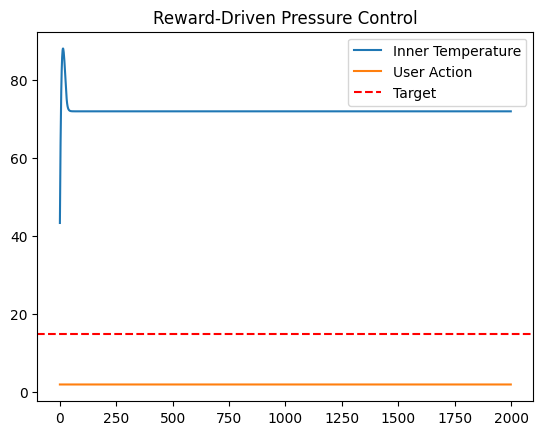

In [21]:
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from datetime import datetime

innert_temp_history = []
action_history = []
reward_history = []
repeat_cnt = 1

def test_model(model_path_name, repeat_cnt=100, debug=False):
    # 저장된 모델 로드 및 테스트
    env = DryerEnv(debug=debug)
    model = RecurrentPPO.load(model_path_name)
    model.env = env
    if isinstance(model.action_space, gym.spaces.Discrete):
        print("이 모델은 [이산(Discrete)] 환경용입니다. (Logits 사용 가능)")
    elif isinstance(model.action_space, gym.spaces.Box):
        print("이 모델은 [연속(Continuous)] 환경용입니다. (Logits 없음, MSE 사용 필요)")
    print(f'테스트를 시작합니다. [{datetime.now()}]')
    
    obs, _ = model.env.reset()
    # LSTM 상태 초기화 (Recurrent 모델은 상태 관리가 필요함)
    lstm_states = None
    episode_starts = np.ones((1,), dtype=bool)
    for i in range(repeat_cnt):
        # 모델 예측 (deterministic=True: 가장 확률 높은 액션 선택)
        print( f"obs={obs}")        
        action, lstm_states = model.predict(
            obs, 
            state=lstm_states, 
            episode_start=episode_starts, 
            deterministic=True
        )
        action = int(action)
        obs, reward, terminated, truncated, _ = model.env.step(action)
        print( f"Step {i}: Temp={obs[0]:.2f}, RPM={obs[6]:.2f}, Action={action}, Reward={reward:.2f}, obs={obs}")
        # if i % 10 == 0:
        #     model.learn(total_timesteps=10)
        #     print( f"Step {i}: Temp={obs[0]:.2f}, Action={action}, Reward={reward:.2f}")
        innert_temp_history.append(obs[0])
        action_history.append(action)
        # reward_history.append(reward)
        
        # if terminated or truncated:
        #     break

test_model(model_path_name=model_path_name, repeat_cnt=2000, debug=False)

plt.plot(innert_temp_history, label='Inner Temperature')
plt.plot(action_history, label='User Action')
# plt.plot(reward_history, label='Reward')
plt.axhline(15, color='r', linestyle='--', label='Target')
plt.title("Reward-Driven Pressure Control")
plt.legend()
plt.show()
# plt.plot(press_history, label='Air Pressure (Pa)')
# plt.axhline(15, color='r', linestyle='--', label='Target')
# plt.title("Reward-Driven Pressure Control")
# plt.legend()
# plt.show()